In [14]:
import math
import time
import numpy
import os
import matplotlib.pyplot as mp
import matplotlib.patches as mpp
import matplotlib.dates as mpd
import pandas

import netCDF4 as nc

import xarray as xr

%matplotlib inline


In [15]:
folder_path = '../Data/'

file_list = []

for e in os.scandir(folder_path):
    if e.is_file():
        if e.name.endswith("nc"):
            file_list.append(e.path)
            #print("Content of", e.name, ":")
print(sorted(file_list))

['../Data/2024__1021341_Binned.nc', '../Data/2024__1021342.001_Binned.nc', '../Data/2024__1021342_Binned.nc', '../Data/2024__1021344_0001_Binned.nc', '../Data/2024__1021344_Binned.nc', '../Data/2024__1021345_Binned.nc', '../Data/2024__1021347_0001_Binned.nc', '../Data/2024__1021347_0002_Binned.nc', '../Data/2024__1021347_Binned.nc', '../Data/2024__1021348_Binned.nc', '../Data/2024__1021350_Binned.nc', '../Data/2024__1021353_Binned.nc', '../Data/2024__1021354_0001_Binned.nc', '../Data/2024__1021354_Binned.nc', '../Data/2024__1021355_Binned.nc', '../Data/2024__1021356_Binned.nc', '../Data/2024__1021358_Binned.nc', '../Data/2024__1021359_0001_Binned.nc', '../Data/2024__1021359_Binned.nc', '../Data/2024__1021400.001_Binned.nc', '../Data/2024__1021400_Binned.nc', '../Data/2024__1021402_0001_Binned.nc', '../Data/2024__1021403_0001_Binned.nc', '../Data/2024__1021403_Binned.nc', '../Data/2024__1021404_0001_Binned.nc', '../Data/2024__1021404_Binned.nc', '../Data/2024__1021405_Binned.nc', '../Da

In [26]:
file_path = '../Dataset Metric/2024__0930834_Binned.nc'
dt = xr.open_datatree(file_path)

print(dt)


filename = os.path.basename(file_path)


<xarray.DataTree>
Group: /
│   Attributes:
│       Vessel name:      Marindin 6205
│       Survey area:      Provincetown bay
│       Export version:   1.0
│       Survey file:      2024__0930834_Binned
│       Export date:      2026-06-02T14:38:38Z
│       deltaX positive:  starboard
│       deltaY positive:  forward
│       deltaZ positive:  down
│       roll positive:    port up
│       pitch positive:   bow up
│       yaw positive:     clockwise
├── Group: /Environment
│   └── Group: /Environment/Sound Velocity
│           Dimensions:         (time: 95)
│           Coordinates:
│             * time            (time) datetime64[ns] 760B 2024-04-02T12:31:09.895000 ......
│           Data variables:
│               sound_velocity  (time) float64 760B ...
│           Attributes:
│               comment:  Sound velocity
│               sensor:   ?
├── Group: /Platform
│   ├── Group: /Platform/Position
│   │       Dimensions:    (timetag: 954)
│   │       Coordinates:
│   │         * tim

# Analyse de la bathymétrie

In [27]:
# Find the correct attitude and heave for the given timetag
def find_nav (timetag_data, data, timetag_sample) :

    idx = numpy.searchsorted(timetag_data, timetag_sample)

    idx = idx-1
    if idx < 0:
        idx = 0
  
    delta = timetag_sample-timetag_data[idx]
 
    return data[idx] + delta * (data[idx+1]-data[idx]) / (timetag_data[idx+1]-timetag_data[idx])


In [28]:
# Bottom profile from one ping, corrected with roll and heve effect
def compute_profile (dt , ping_number) :

    # Load the bathy time data
    ping_timetag = dt['/Sonar/Bathymetry/Port/Block_0/timetag'][ping_number] # temps au quel une impulsion est envoyé ( et écouté)

    bathy_port_0_time = dt['/Sonar/Bathymetry/Port/Block_0/time'][ping_number,:] ## temps entre le début d impulsion et un réception ? coté droit
    bathy_stbd_0_time = dt['/Sonar/Bathymetry/Starboard/Block_0/time'][ping_number,:] ## coté gauche

    # Qualité des données
    bathy_port_0_quality = dt['/Sonar/Bathymetry/Port/Block_0/quality'][ping_number,:] # Qualité des données reçues. Pour chaque temps reception ? [  [] -> sample ] -> ping
    bathy_stbd_0_quality = dt['/Sonar/Bathymetry/Starboard/Block_0/quality'][ping_number,:]

    # Compute the timetag for every sample
    bathy_port_0_timetag = ping_timetag + (bathy_port_0_time * 1e9).astype('timedelta64[ns]') #? Temps de reception absolu pour chaque sample
    bathy_stbd_0_timetag = ping_timetag + (bathy_stbd_0_time * 1e9).astype('timedelta64[ns]') #? Temps de reception absolu pour chaque sample

    # Load the attitude data
    time_attitude = dt['/Platform/Attitude/timetag'] # temps absolue à chaque mesure du roulis
    roll = dt['/Platform/Attitude/roll'] # mesure du roulis 

    # Compute the roll for every sample based on its timetag
    roll_smp_port = [find_nav (time_attitude, roll, bathy_port_0_timetag[k]) for k in range(400)]  # calcule du roll pour chaque reception d'une donnée pour un ping donné coté gauche cf image
    roll_smp_stbd = [find_nav (time_attitude, roll, bathy_stbd_0_timetag[k]) for k in range(400)]  # calcule du roll pour chaque reception d'une donnée pour un ping donné coté droit

    # Correct the beam roll with the attitude roll at reception time
    bathy_port_0_angle = dt['/Sonar/Bathymetry/Port/Block_0/angle'][ping_number,:] # correction du roulis de l impulsion recue avec le roulis du sonar, on pourrait voir ça comme un roulis absolue
    bathy_port_0_angle_roll = bathy_port_0_angle - roll_smp_port - 0.18

    bathy_stbd_0_angle = dt['/Sonar/Bathymetry/Starboard/Block_0/angle'][ping_number,:]  # pareille mais coté droit
    bathy_stbd_0_angle_roll = bathy_stbd_0_angle - roll_smp_stbd + 0.28

    # Compute the bottom profile
    x_port_roll = 1475.*bathy_port_0_time/2.0*numpy.sin(bathy_port_0_angle_roll* numpy.pi / 180.) # calcul x coté droit =  vitesse * delta temps * sin ( angle entre l observe et la droite formé par la position du bateau et le vecteur suivant la force gravitationelle )
    z_port_roll = -1475.*bathy_port_0_time/2.0*numpy.cos(bathy_port_0_angle_roll* numpy.pi / 180.) # calcul y


    x_stbd_roll = 1475.*bathy_stbd_0_time/2.0*numpy.sin(bathy_stbd_0_angle_roll* numpy.pi / 180.) # calcul x coté gauche
    z_stbd_roll = -1475.*bathy_stbd_0_time/2.0*numpy.cos(bathy_stbd_0_angle_roll* numpy.pi / 180.) # calcule y

    # Heave correction
    time_heave = dt['/Platform/Heave/timetag'] # temps a chaque mesure de la houle
    heave = dt['/Platform/Heave/heave'] # houle

    # Compute the roll for every sample based on its timetag
    heave_smp_port = [find_nav (time_heave, heave, bathy_port_0_timetag[k]) for k in range(400)]
    heave_smp_stbd = [find_nav (time_heave, heave, bathy_stbd_0_timetag[k]) for k in range(400)]

    # Filtering bad samples
    bad_samples = bathy_port_0_quality[:] == 0
    x_port = numpy.delete(x_port_roll,bad_samples)
    z_port = numpy.delete(z_port_roll-heave_smp_port,bad_samples)

    bad_samples = bathy_stbd_0_quality[:] == 0
    x_stbd = numpy.delete(x_stbd_roll,bad_samples)
    z_stbd = numpy.delete(z_stbd_roll-heave_smp_stbd,bad_samples)

    return x_port, z_port, x_stbd, z_stbd


### Calcul de quelques profils de terrain

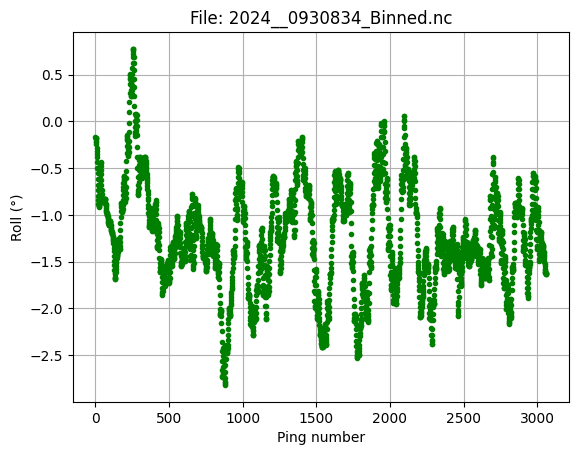

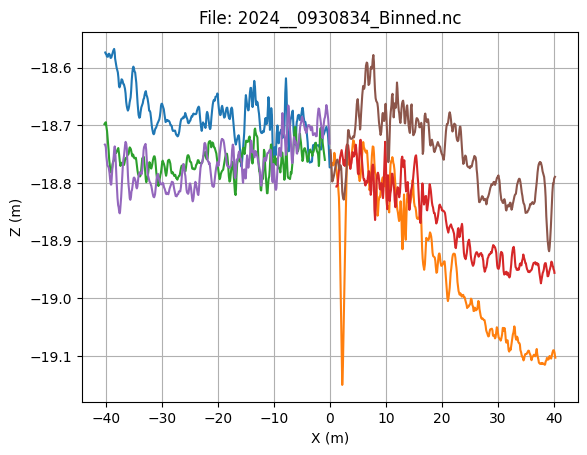

In [ ]:
# Load Attitude data and heave
time_attitude = dt['/Platform/Attitude/timetag']
roll = dt['/Platform/Attitude/roll']
pitch = dt['/Platform/Attitude/pitch']

fig, ax = mp.subplots()
ax.set_title("File: "+filename)
ax.xaxis.set_label_text("Ping number")
ax.yaxis.set_label_text("Roll (°)")
ax.grid(True)
ax.plot(roll, 'g.', label="angle(roll)")
mp.show()

ping_numbers = [100, 150]

fig, ax = mp.subplots()
ax.set_title("File: "+filename)
ax.set_title("File: "+filename)
ax.xaxis.set_label_text("X (m)")
ax.yaxis.set_label_text("Z (m)")
ax.grid(True)
for ping in ping_numbers :
    x_port, z_port, x_stbd, z_stbd = compute_profile (dt, ping)
    ax.plot(x_port, z_port)
    ax.plot(x_stbd, z_stbd)
mp.show()


# Analyse des images

In [ ]:
print(dt['/Sonar/Bathymetry/Port/Block_0/time'][0,:].values)
#mp.plot(, dt['/Sonar/Bathymetry/Port/Block_0/angle'][0,:])

[0.10069206 0.10069206 0.10094242 0.10116973 0.1012112  0.1012112
 0.1012112  0.00486727 0.00486727 0.00486727 0.00486727 0.00485805
 0.00484269 0.00483808 0.00484269 0.00485344 0.00487187 0.00488877
 0.00491181 0.00494099 0.00497632 0.00500703 0.00502393 0.00503775
 0.00505465 0.00507461 0.00511608 0.00516523 0.00520363 0.00522667
 0.00523435 0.00523128 0.00523128 0.00527735 0.00535108 0.0053864
 0.00540176 0.00543094 0.00546166 0.00550774 0.00556764 0.00561218
 0.00562907 0.00560296 0.00560143 0.00566133 0.00571662 0.00575809
 0.00580724 0.0058656  0.00591936 0.00595315 0.00598847 0.00600844
 0.00604069 0.00611595 0.00618814 0.00622961 0.00626954 0.00631101
 0.00633712 0.00637398 0.00643081 0.00648303 0.00653679 0.0065844
 0.00661819 0.0066612  0.0067211  0.00676871 0.00680864 0.00686087
 0.00690387 0.00695148 0.00702367 0.00707282 0.00710968 0.00716344
 0.00721259 0.00724791 0.00729399 0.00735543 0.00739997 0.00744451
 0.00750441 0.00756124 0.00761653 0.00767028 0.00773018 0.0077916

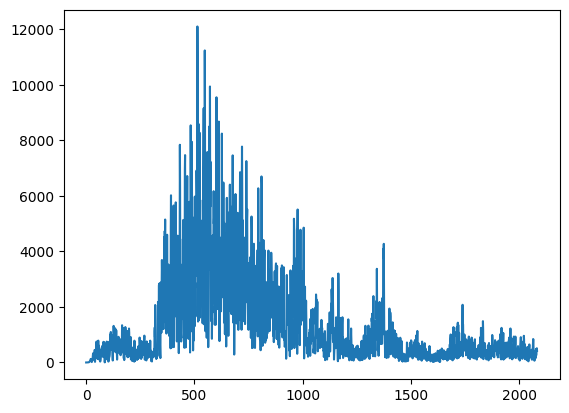

In [ ]:
lf_port_0 = dt['/Sonar/SLS LF/Port/Block_0/samples']

mp.plot(lf_port_0[0].values)

#### LF Sidescan images

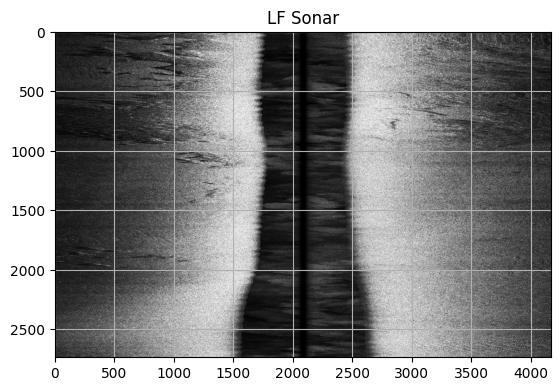

In [ ]:
# Load the sonar images
lf_port_0 = dt['/Sonar/SLS LF/Port/Block_0/samples']
lf_starboard_0 = dt['/Sonar/SLS LF/Starboard/Block_0/samples']

# Build a waterfall view
nb_pings = lf_port_0.sizes['nb_pings']
nb_samples = lf_port_0.sizes['nb_samples']
img = numpy.zeros((nb_pings,2*nb_samples))
img[:,0:nb_samples] = numpy.fliplr(lf_port_0)
img[:,nb_samples:2*nb_samples] = lf_starboard_0

# Show the waterfall view
mp.imshow(img,cmap='gray' ,vmin=0, vmax=4000)
mp.grid(True)
mp.title ('LF Sonar')
mp.show()


#### HF Sidescan images

5092


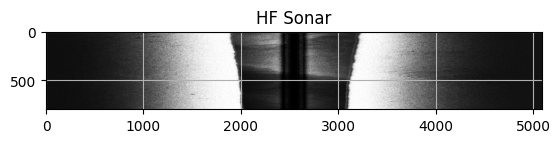

In [ ]:
# Load the sonar images
lf_port_0 = dt['/Sonar/SLS HF/Port/Block_0/samples']
lf_starboard_0 = dt['/Sonar/SLS HF/Starboard/Block_0/samples']

# Build a waterfall view
nb_pings = lf_port_0.sizes['nb_pings']
nb_samples = lf_port_0.sizes['nb_samples']
print(nb_samples*2)
img = numpy.zeros((nb_pings,2*nb_samples))
img[:,0:nb_samples] = numpy.fliplr(lf_port_0)
img[:,nb_samples:2*nb_samples] = lf_starboard_0

# Show the waterfall view
mp.imshow(img,cmap='gray' ,vmin=0, vmax=20)
mp.grid(True)
mp.title ('HF Sonar')
mp.show()

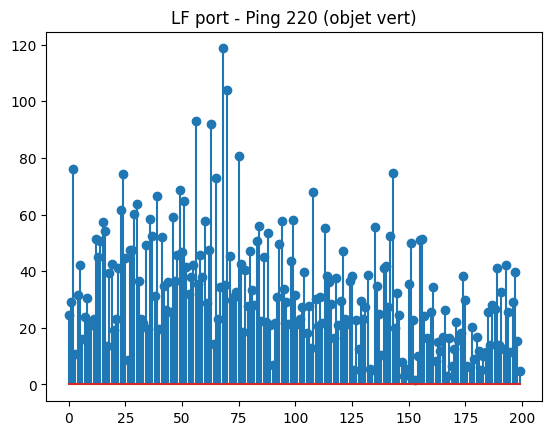

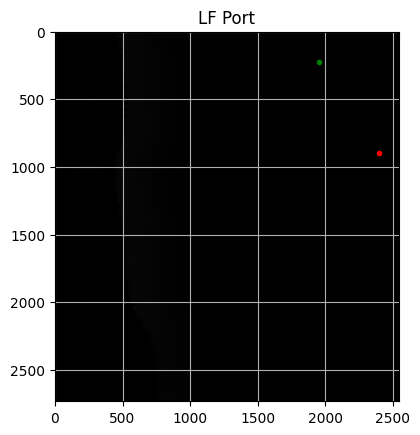

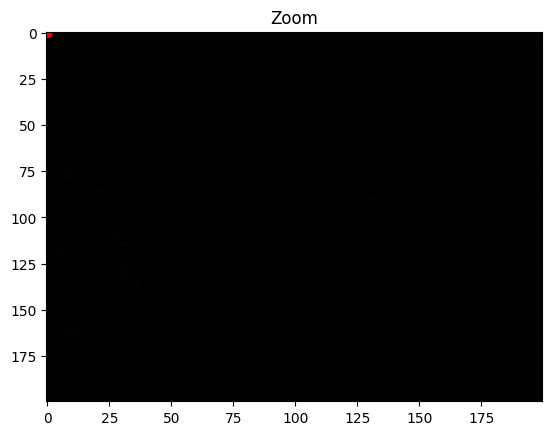

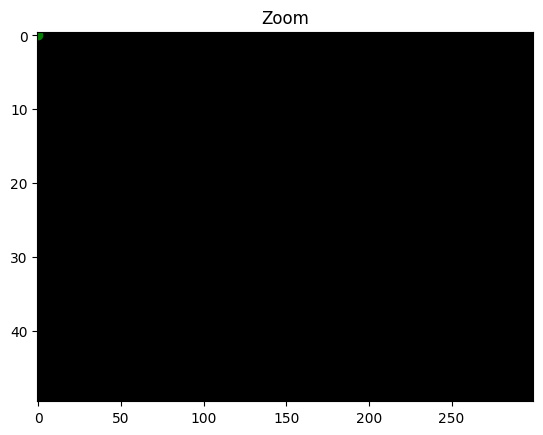

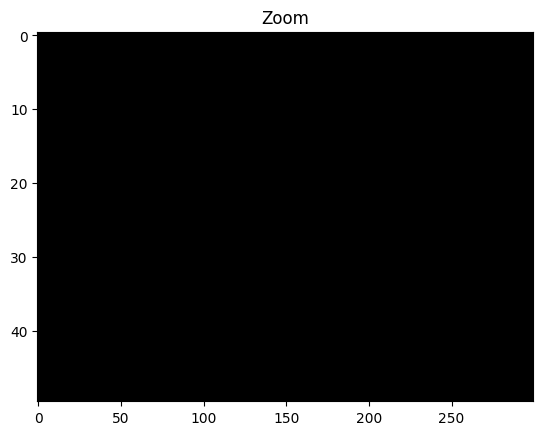

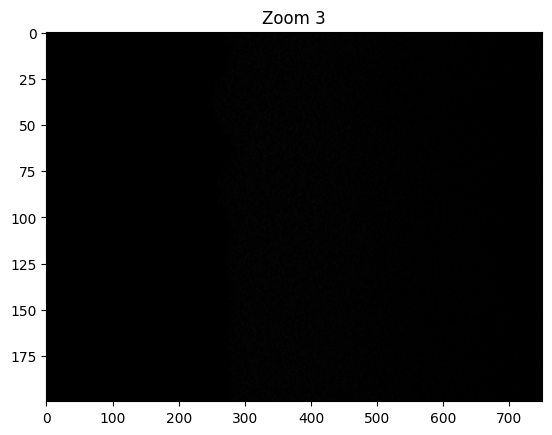

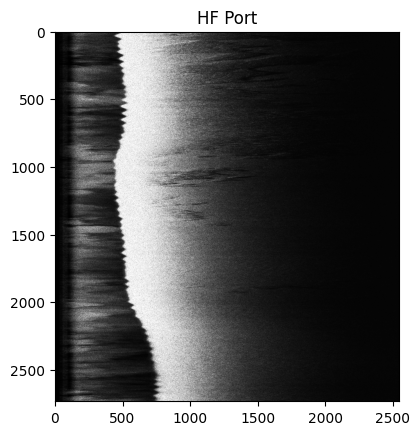

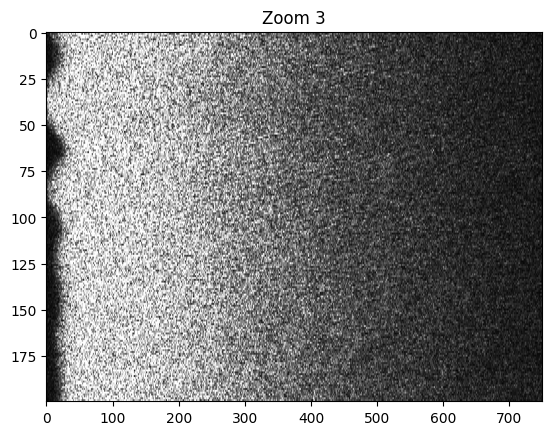

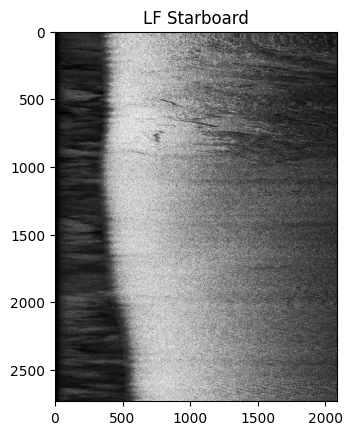

In [ ]:


mp.stem(lf_port_0[220,800:1000])
mp.title('LF port - Ping 220 (objet vert)')
mp.show()



mp.imshow(lf_port_0,cmap='gray' ,vmin=0, vmax=4000)
mp.grid(True)
mp.title ('LF Port')
mp.plot(2400,900,'r.')
mp.plot(1950,225,'g.')
mp.show()

mp.imshow(lf_port_0[900:1100,900:1100],cmap='gray' ,vmin=0, vmax=4000, aspect='auto')
mp.plot(0,0,'ro')
mp.title ('Zoom')
mp.show()
mp.imshow(lf_port_0[200:250,2000:2300],cmap='gray' ,vmin=0, vmax=4000, aspect='auto')
mp.plot(0,0,'go')
mp.title ('Zoom')
mp.show()
mp.imshow(lf_port_0[1425:1475,1350:1650],cmap='gray' ,vmin=0, vmax=6000, aspect='auto')
mp.title ('Zoom')
mp.show()
mp.imshow(lf_port_0[1600:1800,250:1000],cmap='gray' ,vmin=0, vmax=8000, aspect='auto')
mp.title ('Zoom 3')
mp.show()


hf_port_0 = dt['/Sonar/SLS HF/Port/Block_0/samples']
mp.title ('HF Port')
mp.imshow(hf_port_0,cmap='gray' ,vmin=0, vmax=50)
mp.show()

mp.imshow(hf_port_0[1600:1800,500:1250],cmap='gray' ,vmin=0, vmax=100, aspect='auto')
mp.title ('Zoom 3')
mp.show()

lf_stbd_0 = dt['/Sonar/SLS LF/Starboard/Block_0/samples']
mp.imshow(lf_stbd_0,cmap='gray' ,vmin=0, vmax=4000)
mp.title ('LF Starboard')
mp.show()


# Platform position

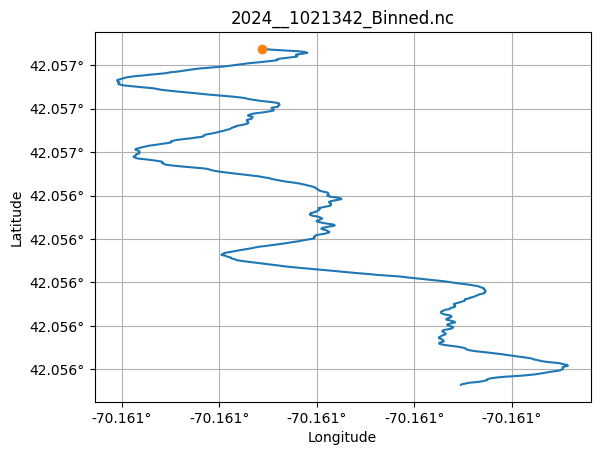

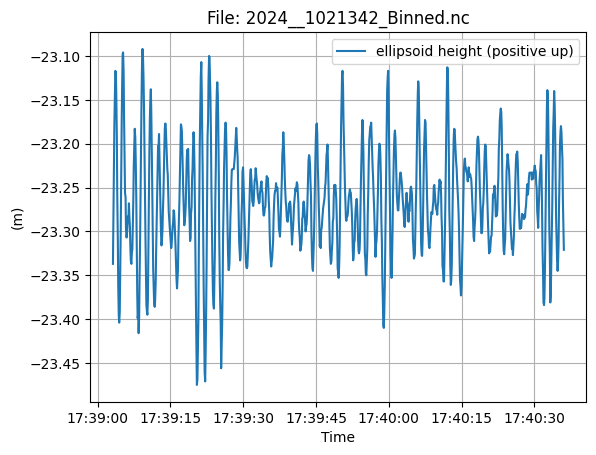

In [ ]:
#
# Platform position
# 

# Read the data
time_position = dt['/Platform/Position/timetag']
lat = dt['/Platform/Position/latitude']
lon = dt['/Platform/Position/longitude']
height = dt['/Platform/Position/height']

# Ship path
fig, ax = mp.subplots()
ax.set_title(filename)
ax.xaxis.set_major_formatter(mp.FormatStrFormatter("%0.3f°"))
ax.xaxis.set_label_text("Longitude")
ax.yaxis.set_major_formatter(mp.FormatStrFormatter("%0.3f°"))
ax.yaxis.set_label_text("Latitude")
ax.grid(True)
ax.plot(lon, lat)
ax.plot(lon[0],lat[0],'o')
mp.show()

# Ship height (from geoid)
fig, ax = mp.subplots()
ax.set_title("File: "+filename)
ax.xaxis.set_label_text("Time")
ax.yaxis.set_label_text("(m)")
ax.grid(True)
ax.plot(time_position, height, label='ellipsoid height (positive up)')
mp.legend()
mp.show()

# Platform Heading

0.0


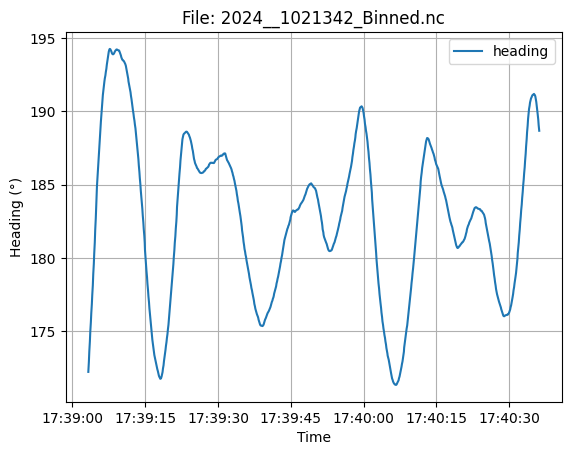

In [ ]:
# Read the data
time_attitude = dt['/Platform/Heading/timetag']
heading = dt['/Platform/Heading/heading']

# Get the compass offset
offset = dt['/Platform/Heading/heading'].attrs['offset']
print(offset)

fig, ax = mp.subplots()
ax.set_title("File: "+filename)
ax.xaxis.set_label_text("Time")
ax.yaxis.set_label_text("Heading (°)")
ax.grid(True)
ax.plot(time_attitude, heading, label="heading")
mp.legend()
mp.show()

# Platform Attitude

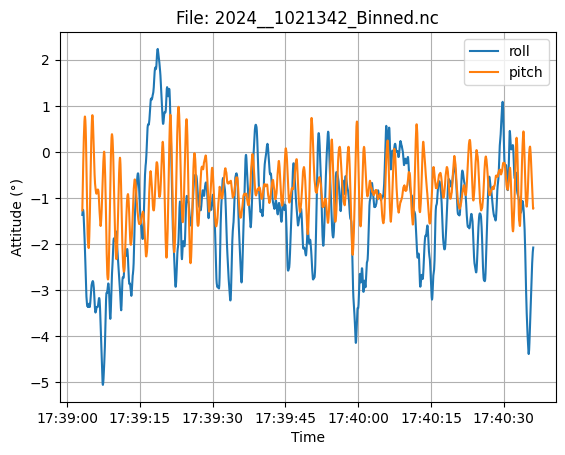

In [ ]:
#
# Platform attitude
#

# Read the data
time_attitude = dt['/Platform/Attitude/timetag']
roll = dt['/Platform/Attitude/roll']
pitch = dt['/Platform/Attitude/pitch']

# Plot
fig, ax = mp.subplots()
ax.set_title("File: "+filename)
ax.xaxis.set_label_text("Time")
ax.yaxis.set_label_text("Attitude (°)")
ax.grid(True)
ax.plot(time_attitude, roll, label='roll')
ax.plot(time_attitude, pitch, label='pitch')
mp.legend()
mp.show()

# Platform Heave

0.0


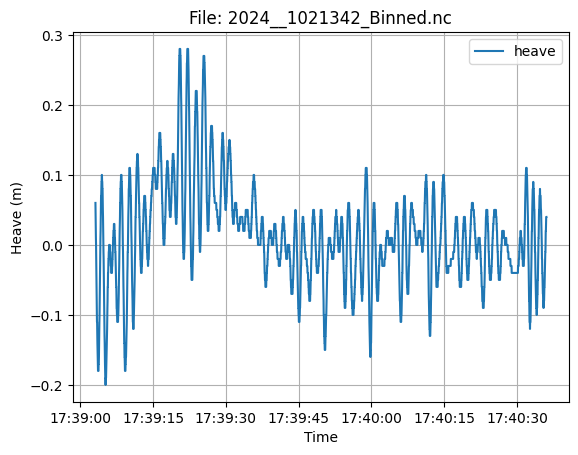

In [ ]:
# Read the data
time_heave = dt['/Platform/Heave/timetag']
heave = dt['/Platform/Heave/heave']

# Get the compass offset
offset = dt['/Platform/Heave/heave'].attrs['offset']
print(offset)

fig, ax = mp.subplots()
ax.set_title("File: "+filename)
ax.xaxis.set_label_text("Time")
ax.yaxis.set_label_text("Heave (m)")
ax.grid(True)
ax.plot(time_heave, heave, label='heave')
mp.legend()
mp.show()

# Altitude / Depth / Height

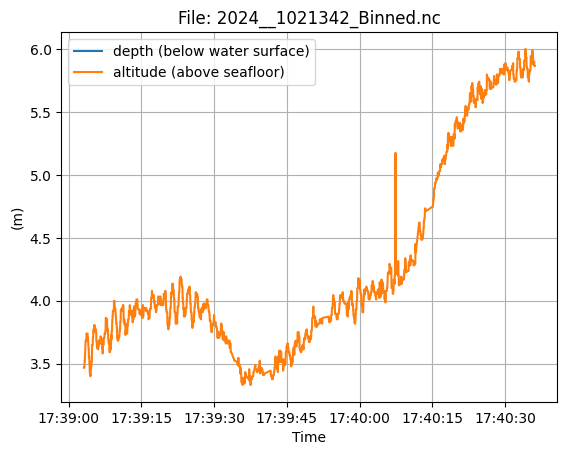

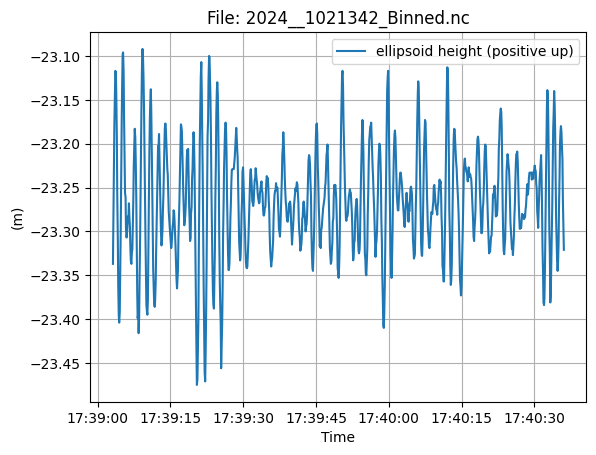

In [ ]:
# Read the data
time_depth = dt['/Platform/Depth/timetag']
depth = dt['/Platform/Depth/depth']
time_altitude = dt['/Platform/Altitude/timetag']
altitude = dt['/Platform/Altitude/altitude']
time_height = dt['/Platform/Position/timetag']
height = dt['/Platform/Position/height']

fig, ax = mp.subplots()
ax.set_title("File: "+filename)
ax.xaxis.set_label_text("Time")
ax.yaxis.set_label_text("(m)")
ax.grid(True)
ax.plot(time_depth, depth, label='depth (below water surface)')
ax.plot(time_altitude, altitude, label='altitude (above seafloor)')
mp.legend()
mp.show()

fig, ax = mp.subplots()
ax.set_title("File: "+filename)
ax.xaxis.set_label_text("Time")
ax.yaxis.set_label_text("(m)")
ax.grid(True)
ax.plot(time_height, height, label='ellipsoid height (positive up)')
mp.legend()
mp.show()

# Sound Velocity

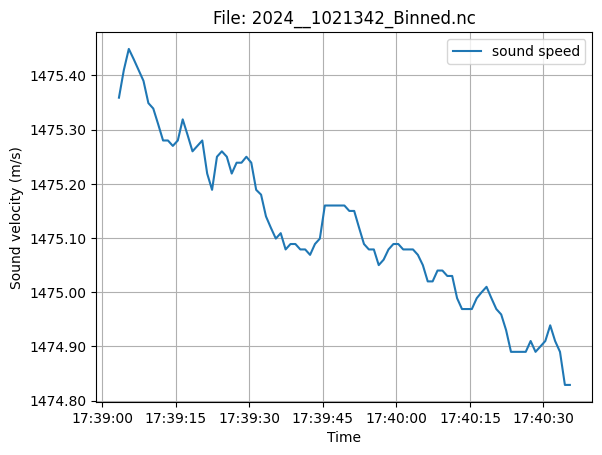

In [ ]:
# Read the data
time_sound_speed = dt['/Environment/Sound Velocity/time']
sound_speed = dt['/Environment/Sound Velocity/sound_velocity']

fig, ax = mp.subplots()
ax.set_title("File: "+filename)
ax.xaxis.set_label_text("Time")
ax.yaxis.set_label_text("Sound velocity (m/s)")
ax.yaxis.set_major_formatter(mp.FormatStrFormatter("%0.2f"))
ax.grid(True)
ax.plot(time_sound_speed, sound_speed, label='sound speed')
mp.legend()
mp.show()

In [ ]:

time_lf = dt['/Sonar/SLS LF/Port/Block_0/timetag']

#print(time_lf)

#t_min = [time_lf.min(),time_position.min()),time_attitude.min()]
#t_max = numpy.max([numpy.max(time_lf),numpy.max(time_position),numpy.max(time_attitude)])

#time_lf_based = (time_lf - t_min)/1e9
#time_position_based = (time_position - t_min)/1e9
#time_attitude_based = (time_attitude - t_min)/1e9

tm_lf = numpy.ones(time_lf.size)

tm_attitude = numpy.ones(time_attitude.size)
tm_position = numpy.ones(time_position.size)



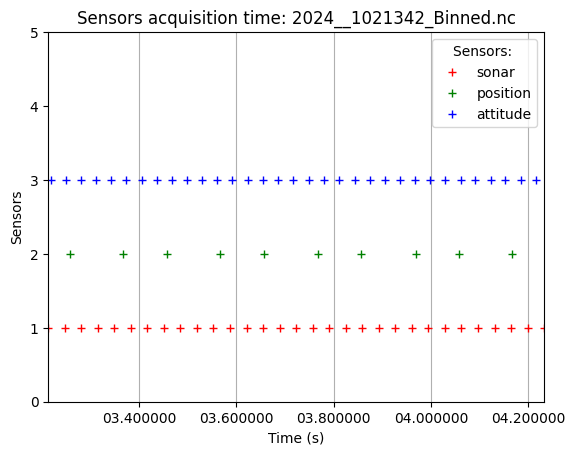

In [ ]:

fig, ax = mp.subplots()
time_start = time_lf[0]
time_end = time_lf[30]

ax.set_xlim([time_start,time_end])
ax.set_ylim([0, 5])
ax.xaxis.set_major_formatter(mpd.DateFormatter('%S.%f'))
ax.xaxis.set_label_text("Time (s)")
ax.yaxis.set_label_text("Sensors")
mp.plot(time_lf,tm_lf,'r+',label="sonar")
mp.plot(time_position,2*tm_position,'g+',label="position")
mp.plot(time_attitude,3*tm_attitude,'b+',label="attitude")
mp.grid(which='both',axis='x')
mp.legend(title='Sensors: ')
mp.title("Sensors acquisition time: "+filename)
mp.show()



In [ ]:
dt.close()

In [ ]:
# Open the netcdf file
data = nc.Dataset('../Data/test.nc', mode="r")

print(data)


FileNotFoundError: [Errno 2] No such file or directory: '../Data/test.nc'